# Task 3 — Merged-Data Analysis

The cleaning notebook already built the master table (every line joined to both of
its substations and its owning utility — see `griddata.build_master` for the join
logic and its row-count checks). This notebook uses it to answer the questions that
need columns from more than one CSV at a time.

In [1]:
import sys

sys.path.append("../src")

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

import griddata

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110

data, _ = griddata.clean(griddata.load_raw())
master = griddata.build_master(data)

OUT = "../outputs"
master[["Code", "Source Substation", "Region_src", "Destination Substation", "Region_dst",
        "Voltage (kV)", "Length (km)", "Inter-regional", "Cross-border"]].head()

,Code,Source Substation,Region_src,Destination Substation,Region_dst,Voltage (kV),Length (km),Inter-regional,Cross-border
0,NED,Achimota Substation,Greater Accra,Tema Substation,Greater Accra,11,25.2,False,False
1,NED,Achimota Substation,Greater Accra,Mallam Substation,Greater Accra,11,11.0,False,False
2,GRD,Achimota Substation,Greater Accra,Kaneshie Substation,Greater Accra,11,5.9,False,False
3,ECG,Tema Substation,Greater Accra,Mallam Substation,Greater Accra,330,34.4,False,False
4,GRD,Tema Substation,Greater Accra,Legon Substation,Greater Accra,161,19.5,False,False


## Which utility/region combinations operate the most lines?

"Region" for a line is taken from its **source** substation here, which is the
convention the brief uses. It's worth being explicit because 16 lines cross a region
boundary, and for those the choice of end changes the answer.

,Code,Region_src,Lines
0,GRD,Greater Accra,5
1,NED,Greater Accra,4
2,GRD,Bono,3
3,GRD,Eastern,3
4,NED,Central,3
5,GRD,Volta,3
6,NED,Ashanti,3
7,GRD,Western,3
8,GRD,Ashanti,2
9,CIE,Cote d'Ivoire border,2


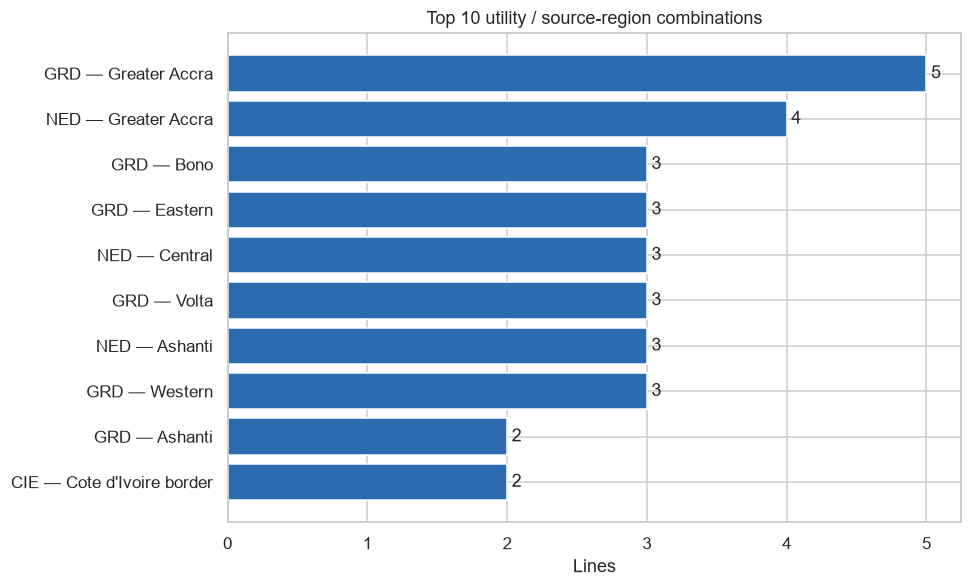

In [2]:
combo = (
    master.groupby(["Code", "Region_src"], observed=True)
    .size()
    .rename("Lines")
    .sort_values(ascending=False)
    .reset_index()
)

top10 = combo.head(10).iloc[::-1]
fig, ax = plt.subplots(figsize=(9, 5.5))
labels = top10["Code"] + " — " + top10["Region_src"]
ax.barh(labels, top10["Lines"], color="#2b6cb0")
ax.set_xlabel("Lines")
ax.set_title("Top 10 utility / source-region combinations")
ax.bar_label(ax.containers[0], padding=3)
fig.tight_layout()
fig.savefig(f"{OUT}/m1_utility_region_combos.png", bbox_inches="tight")
combo.head(10)

The top slots are the big southern regions split among ECG, NEDCo and GRIDCo.
NEDCo appearing in southern regions (it's the *northern* distribution company in
reality) is a generator artefact — line ownership is drawn uniformly from
{ECG, NEDCo, GRIDCo} for regional lines — and gets flagged as a realism limitation
in the report rather than interpreted as a finding.

## How does line length vary by voltage tier?

This was the open question we logged at the end of the EDA notebook. Expectation
from how grids are built: higher-voltage lines run further.

,count,median,max
Voltage (kV),,,
11,14,81.0,152.5
33,8,66.3,87.3
69,9,64.2,117.8
161,7,17.1,86.6
330,17,175.4,426.0


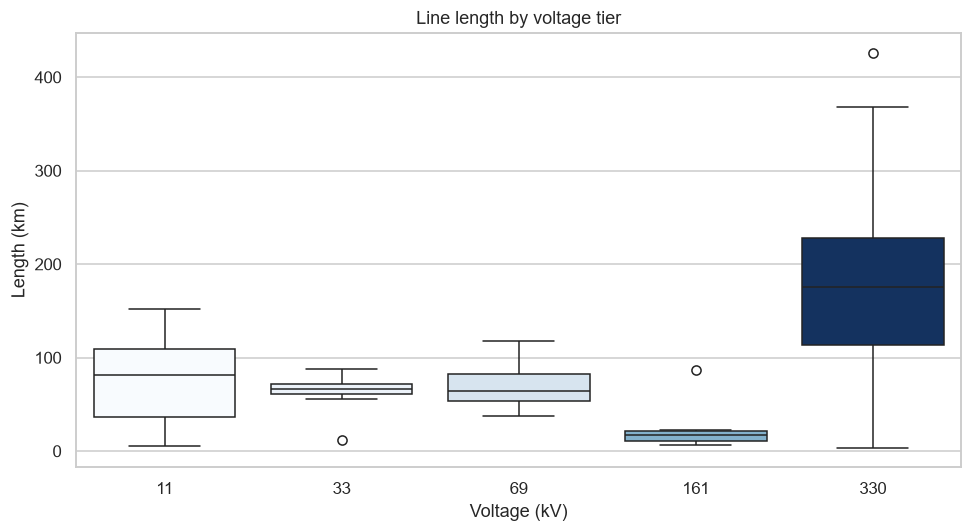

In [3]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=master, x="Voltage (kV)", y="Length (km)", hue="Voltage (kV)",
            palette="Blues", legend=False, ax=ax)
ax.set_title("Line length by voltage tier")
fig.tight_layout()
fig.savefig(f"{OUT}/m2_length_by_voltage.png", bbox_inches="tight")
master.groupby("Voltage (kV)", observed=True)["Length (km)"].agg(["count", "median", "max"]).round(1)

Clear as expected: 330 kV lines are the long-haul backbone and border links (median
well over 100 km), everything below 161 kV stays within its region. The mechanism in
this dataset is structural — the generator assigns 330 kV to exactly the backbone and
cross-border links, and a line between two regional substations otherwise takes the
*lower* of its two endpoint voltages. The pattern matches reality, but it's baked in
by construction, not discovered.

## Which region pairs does the backbone actually join?

Pair
Ashanti ↔ Greater Accra                 1
Ashanti ↔ Western                       1
Central ↔ Western                       1
Central ↔ Eastern                       1
Eastern ↔ Volta                         1
Bono ↔ Volta                            1
Bono ↔ Northern                         1
Northern ↔ Upper East                   1
Upper East ↔ Upper West                 1
Burkina Faso border ↔ Upper East        1
Burkina Faso ↔ Burkina Faso border      1
Ashanti ↔ Cote d'Ivoire border          1
Cote d'Ivoire ↔ Cote d'Ivoire border    1
Greater Accra ↔ Togo border             1
Togo ↔ Togo border                      1
Benin ↔ Togo                            1
Name: count, dtype: int64

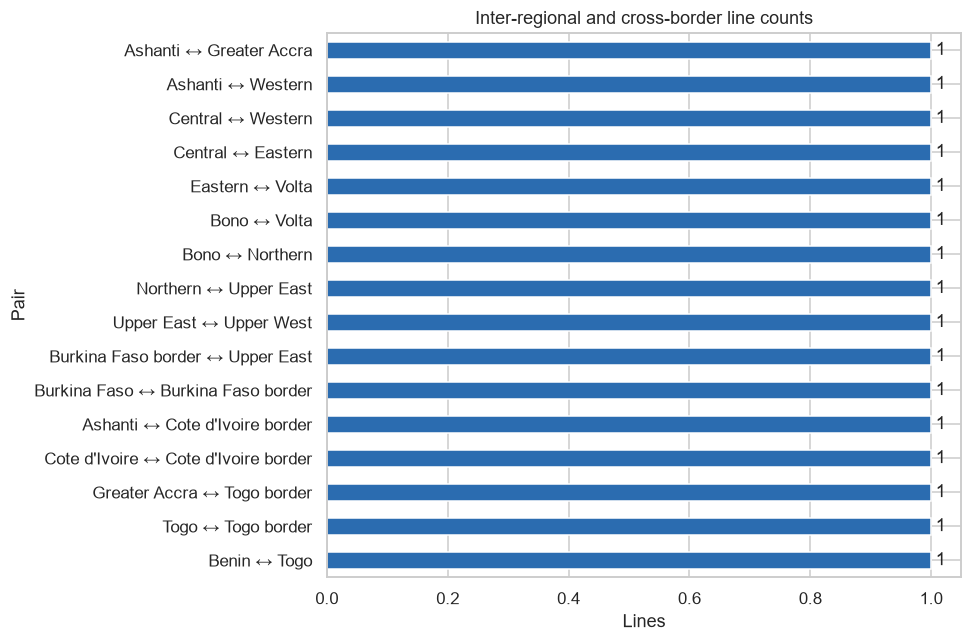

In [4]:
inter = master[master["Inter-regional"]].copy()
# Order the pair alphabetically so Accra->Ashanti and Ashanti->Accra count as one.
inter["Pair"] = inter.apply(
    lambda r: " ↔ ".join(sorted([r["Region_src"], r["Region_dst"]])), axis=1
)
pair_counts = inter["Pair"].value_counts()

fig, ax = plt.subplots(figsize=(9, 6))
pair_counts.plot(kind="barh", ax=ax, color="#2b6cb0")
ax.invert_yaxis()
ax.set_xlabel("Lines")
ax.set_title("Inter-regional and cross-border line counts")
ax.bar_label(ax.containers[0], padding=3)
fig.tight_layout()
fig.savefig(f"{OUT}/m3_region_pairs.png", bbox_inches="tight")
pair_counts

Every pair is joined by exactly **one** line. That's the single most important
structural fact found so far: each of these corridors is a single point of failure
for inter-regional connectivity, and it predicts what the bridge analysis in the
network notebook should find. The backbone follows the generator's hub chain
(Achimota → Kumasi Central → Takoradi → ... → Wa) plus the WAPP border links.

## Utility footprint: substations vs lines

`lines.csv` says who operates the wires. For substations the dataset has no
ownership column, so the footprint compares each utility's *line* count against the
number of distinct substations its lines touch.

,Substations,Lines
Code,,
GRD,26,24
NED,21,14
ECG,18,10
CEB,4,3
CIE,3,2
SNB,3,2


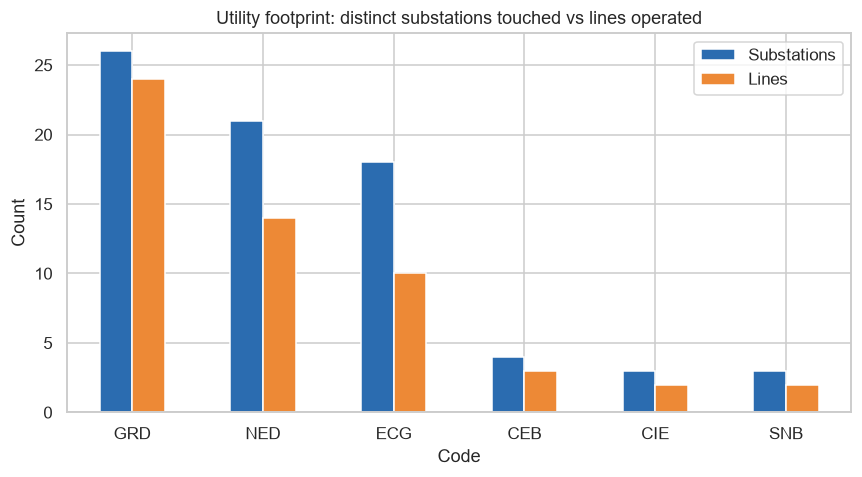

In [5]:
touched = pd.concat([
    master[["Code", "Source Substation"]].rename(columns={"Source Substation": "Substation"}),
    master[["Code", "Destination Substation"]].rename(columns={"Destination Substation": "Substation"}),
])
footprint = (
    touched.groupby("Code", observed=True)
    .agg(Substations=("Substation", "nunique"))
    .join(master.groupby("Code", observed=True).size().rename("Lines"))
    .sort_values("Lines", ascending=False)
)

fig, ax = plt.subplots(figsize=(8, 4.5))
footprint.plot(kind="bar", ax=ax, color=["#2b6cb0", "#ed8936"])
ax.set_title("Utility footprint: distinct substations touched vs lines operated")
ax.set_ylabel("Count")
plt.xticks(rotation=0)
fig.tight_layout()
fig.savefig(f"{OUT}/m4_utility_footprint.png", bbox_inches="tight")
footprint

GRIDCo touches the most substations relative to its line count — consistent with
running the long corridors that string many hubs together rather than dense local
clusters. The two border utilities (SONABEL, CIE/CEB) each touch a handful of
stations via the WAPP links.

In [6]:
master.to_csv("../data/clean_master.csv", index=False)
print("master re-saved with Pair analysis columns available for the dashboard")

master re-saved with Pair analysis columns available for the dashboard


## Issues log for this task

- **No data lost in any merge** — row count 55 before and after, both ends of every
  line resolved (asserted inside `build_master`, so a regression fails loudly).
- **Convention choice**: line region = source substation's region; stated wherever
  used.
- **Realism limits**: uniform utility assignment puts NEDCo in the south; region
  labels for border stations hold the neighbouring country's name. Both noted for
  the report's limitations section.